# Week 4 Day 3

# Feature Engineering, Cross-Validation & Model Comparison
## Scenario
Today you'll expand the feature set with principled feature engineering and use cross-validation to compare models more reliably. Goal: find features that materially improve performance, and get statistically believable performance estimates before tuning.

### Task 1: Create & Justify Engineered Features
- Propose and build at least 6 new features. Examples:
    - Age buckets
    - Hours-per-week bins
    - Flag: capital_gain > 0
    - log(capital_gain + 1)
    - Higher-education boolean
    - Interaction: education_num × hours_per_week
- For each feature, give a one-line justification (why it might help) + a univariate predictive score (e.g., mutual_info_classif or grouped mean of target).
- Keep a feature dictionary: name, type, creation rule, predictive signal.


### Task 2: Rebuild Pipeline with Engineered Features
- Integrate the new features cleanly into your preprocessing pipeline (FunctionTransformer or similar).
- No information leakage — features must use only current-row data. No target-encoding yet.


### Task 3: Cross-Validated Model Comparison
- Use StratifiedKFold (k=5) to cross-validate at least 3 models with identical preprocessing:
    - LogisticRegression
    - RandomForestClassifier
    - GradientBoosting (HistGradientBoosting / XGBoost / LightGBM)
- Report mean ± std for your primary metric, plus ROC AUC and F1.
- Visualize with boxplots of fold scores.


### Task 4: Statistical Comparison & Feature Importance
- Run a paired statistical test (paired t-test or Wilcoxon) between your top 2 models on the chosen metric. Report p-values and interpret practically — is the difference actually meaningful?
- Report feature importances (tree-based model) and coefficients (Logistic Regression) for the engineered features. Which engineered features mattered most — and does that make sense?


### Task 5: Feature Selection / Dimensionality Check
- Try a simple feature-selection step (SelectKBest with mutual information, or L1-based selection). Measure the change in cross-validated performance and training time.
- Decide which features to keep for tomorrow's hyperparameter tuning — with a short rationale.


### Deliverable
- A notebook
- A 2-page summary with: engineered feature list → CV comparison plots/tables → statistical test results → recommended models/features for tuning



### Import Libraries 

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_openml

# Train/Test Split
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# average_precision_score computes PR_AUC

# For Baseline Models
from sklearn.dummy import DummyClassifier

# Notebook Settings
pd.set_option("display.max_columns", None) # display all cols

sns.set_style("whitegrid") # clean white bkgrd for plots

## Problem Definition

### Business Objective

The objective is to identify individuals who are likely to earn >50K per year. A company could use this prediction to target premium products or marketing campaigns toward higher-income customers while minimizing unnecessary outreach.

### Target Variable

- Positive Class (1): Income >50K
- Negative Class (0): Income ≤50K

### Primary Evaluation Metric

Precision is selected as the primary evaluation metric because contacting individuals incurs cost. A higher precision means that a larger proportion of contacted individuals actually belong to the high-income group, reducing wasted marketing resources.

Although recall is also important, maximizing precision is more appropriate for this business scenario where false positives are more costly than missing some potential customers.

### Explanation for Non-Technical Stakeholders
We are building a model to help the marketing team identify customers who are more likely to earn over $50,000 per year. This allows the company to focus promotional campaigns on people who are more likely to respond, making better use of the marketing budget. To reduce unnecessary outreach, we prioritize making reliable positive predictions rather than contacting as many people as possible.


### Load Dataset

In [2]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

# version 2 is selected to make the results reproducible
# as_frame is used to get data in the form of Pandas DataFrame

df = adult.frame.copy()

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### Dataset Information

In [3]:
# Dataset Shape

print(f"Dataset Shape: {df.shape}")
print()

# Column Information

df.info()

Dataset Shape: (48842, 15)

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


### Preview Column Names

In [4]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='str')

### Check Missing Values

In [5]:
# The Adult dataset stores missing values as "?" as per given task details
# Check for missing values

missing_values = df.isna().sum()

display(
    missing_values[missing_values > 0].to_frame("Missing Values")
)

,Missing Values
workclass,2799
occupation,2809
native-country,857


### Missing Value Inspection

The Adult dataset obtained from `fetch_openml()` already represents missing values as `NaN` instead of the original `"?"` symbols found in the raw UCI dataset. Missing values were identified in `workclass`, `occupation`, and `native-country`.

In [6]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 52


In [7]:
if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4152,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
40948,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
3900,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
15960,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
33954,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
34979,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
1668,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
19399,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
23271,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
37599,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [8]:
# Remove exact duplicate rows before splitting
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Duplicates removed: {before - after}")

Rows before: 48842
Rows after:  48790
Duplicates removed: 52


### Convert Target to Binary

In [9]:
# first, see existing lables
df["class"].value_counts()

class
<=50K    37109
>50K     11681
Name: count, dtype: int64

In [10]:
# convert them to binary
df["class"] = (
    df["class"].map({
    "<=50K": 0,
    ">50K": 1
})
.astype(int)
)

df["class"].value_counts()

class
0    37109
1    11681
Name: count, dtype: int64

### Base Rate

In [11]:
# compute the class base rate
class_counts = df["class"].value_counts().sort_index()

class_percentages = (
    df["class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

base_rate = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

base_rate

,Count,Percentage
class,,
0,37109,76.06
1,11681,23.94


### Numeric Summary

### Interpretation

The positive class (>50K) represents **23.93%** of the dataset, while **76.07%** of individuals belong to the negative class (≤50K). This indicates that the dataset is moderately imbalanced, making evaluation metrics such as Precision and F1-score more informative than accuracy alone.

In [12]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,class
count,48790.000000,4.879000e+04,48790.000000,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,10.078807,1080.217688,87.595573,40.425886,0.239414
std,13.708493,1.056172e+05,2.570046,7455.905921,403.209129,12.392729,0.426730
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376062e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


### Categorical Summary

In [13]:
df.describe(include="category")

,workclass,education,marital-status,occupation,relationship,race,sex,native-country
count,45995,48790,48790,45985,48790,48790,48790,47934
unique,8,16,7,14,6,5,2,41
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States
freq,33860,15770,22366,6165,19703,41714,32614,43792


### Value Counts

In [14]:
categorical_columns = df.select_dtypes(include="category").columns

for column in categorical_columns:
    print("="*60)
    print(f"Value Counts for '{column}'")
    display(df[column].value_counts().to_frame("Count"))
    print()

Value Counts for 'workclass'


,Count
workclass,
Private,33860
Self-emp-not-inc,3861
Local-gov,3136
State-gov,1981
Self-emp-inc,1694
Federal-gov,1432
Without-pay,21
Never-worked,10



Value Counts for 'education'


,Count
education,
HS-grad,15770
Some-college,10863
Bachelors,8013
Masters,2656
Assoc-voc,2060
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,954



Value Counts for 'marital-status'


...

,Count
race,
White,41714
Black,4683
Asian-Pac-Islander,1517
Amer-Indian-Eskimo,470
Other,406



Value Counts for 'sex'


,Count
sex,
Male,32614
Female,16176



Value Counts for 'native-country'


,Count
native-country,
United-States,43792
Mexico,943
Philippines,294
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155
India,151
Cuba,138


**Observation:**

- The majority of individuals have no capital gain, so only non-zero values are visualized.
- Among individuals with positive capital gains, the distribution is highly right-skewed, with most values clustered at lower gains and a few extremely large values.
- This suggests that `capital-gain` contains significant outliers and may benefit from transformation (e.g., log transformation) or special handling before model training.

# Create Reproducible Data Splits

To evaluate a machine learning model fairly, the dataset is divided into separate subsets. The training set is used to learn patterns from the data, while the hold-out test set is kept completely unseen until the final evaluation. This ensures that the reported performance reflects how well the model generalizes to new, unseen data.

### Separate Features and Target

In [15]:
# Features (Independent Variables)
X = df.drop(columns="class")

# Target (Dependent Variable)
y = df["class"]

### Create Appropriate Data Splits

In [16]:
# Step 1: Create the 20% hold-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# test_size is used to create a test or hold_out split, here 20 % of the data-> 0.20
# we have used stratified sampling and therefore, startify= y for fair evaluation across test and train splits
# we fixed a random state using random_state so that everyone gets the same split everytime thus making this notebook reproducible

# Step 2: Split the remaining 80% into 70% train and 10% development
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train,
    y_train,
    test_size=0.125,
    stratify=y_train,
    random_state=42
)

### Verify Split Sizes

In [17]:
print("Dataset Split Sizes")
print("-" * 30)

print(f"Training Set      : {X_train.shape[0]} samples")
print(f"Development Set   : {X_dev.shape[0]} samples")
print(f"Hold-Out Test Set : {X_test.shape[0]} samples")

Dataset Split Sizes
------------------------------
Training Set      : 34153 samples
Development Set   : 4879 samples
Hold-Out Test Set : 9758 samples


### Verify Stratification

In [18]:
train_distribution = (
    y_train
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

dev_distribution = (
    y_dev
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

test_distribution = (
    y_test
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

comparison = pd.DataFrame({
    "Training (%)": train_distribution.round(2),
    "Development (%)": dev_distribution.round(2),
    "Testing (%)": test_distribution.round(2)
})

comparison.index = ["<=50K", ">50K"]

comparison

,Training (%),Development (%),Testing (%)
<=50K,76.06,76.06,76.06
>50K,23.94,23.94,23.94


## Why is a Hold-Out Test Set Necessary?

A hold-out test set provides an unbiased estimate of how well a machine learning model performs on unseen data. It is kept completely separate during model development and is only used after the final model has been selected.

Using the hold-out test set during hyperparameter tuning introduces **test set leakage**, a form of data leakage where information from the test set indirectly influences model selection. This leads to overly optimistic performance estimates and reduces confidence that the model will generalize well to new, unseen data.

# Baseline Models (From Day 1)

Before training complex machine learning models, simple baseline models are created to establish a minimum performance benchmark. Any future machine learning model should outperform these baselines to demonstrate that it has learned meaningful patterns from the data.

### Majority Class Predictor

In [19]:
# Create the majority-class baseline model
majority_baseline = DummyClassifier(
    strategy="most_frequent"
)

# Train the model
majority_baseline.fit(X_train, y_train)

# Make predictions on the hold-out test set
y_pred_majority = majority_baseline.predict(X_test)

### Evaluate the Baseline

In [20]:
majority_results = {
    "Accuracy": accuracy_score(y_test, y_pred_majority),
    "Precision": precision_score(y_test, y_pred_majority, zero_division=0),
    "Recall": recall_score(y_test, y_pred_majority, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_majority, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_pred_majority),
    "PR AUC": average_precision_score(y_test, y_pred_majority)
}

# zero division is done so that if anywhere during calculations, there comes a result for 0/0, simply take it as 0

pd.DataFrame(
    majority_results,
    index=["Majority Baseline"]
).round(3)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Majority Baseline,0.761,0.0,0.0,0.0,0.5,0.239


### Confusion Matrix

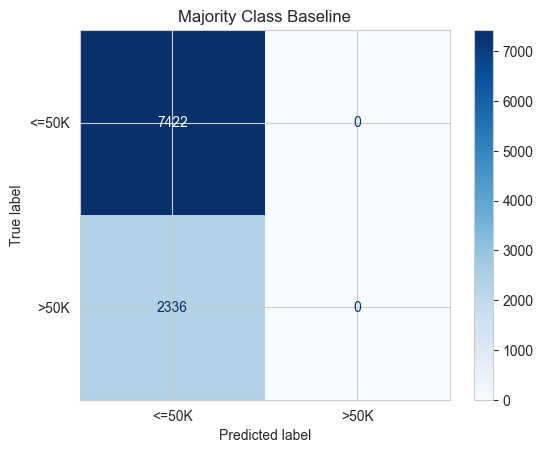

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred_majority
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot(cmap="Blues")

plt.title("Majority Class Baseline")
plt.show()

### Rule-Based Classifier

In [22]:
# Predict >50K if capital-gain > 0

y_pred_rule = (
    X_test["capital-gain"] > 0
).astype(int)

### Evaluate

In [23]:
rule_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rule),
    "Precision": precision_score(y_test, y_pred_rule, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rule, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_rule, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_pred_rule),
    "PR AUC": average_precision_score(y_test, y_pred_rule)
}

pd.DataFrame(
    rule_results,
    index=["Rule-Based Baseline"]
).round(3)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Rule-Based Baseline,0.779,0.608,0.215,0.318,0.586,0.319


### Confusion Matrix

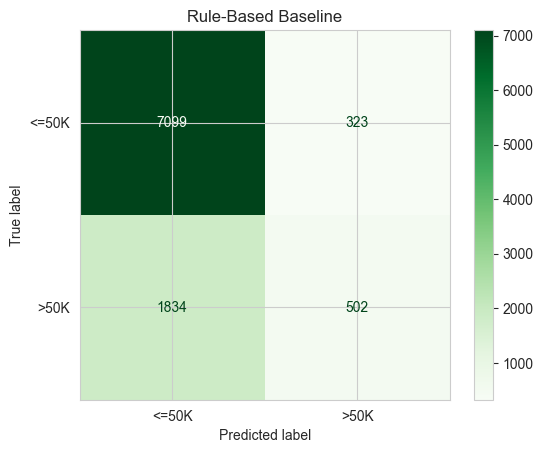

In [24]:
cm = confusion_matrix(
    y_test,
    y_pred_rule
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot(cmap="Greens")

plt.title("Rule-Based Baseline")

plt.show()

### Final Comparison Table

In [25]:
comparison = pd.DataFrame([
    majority_results,
    rule_results
], index=[
    "Majority Baseline",
    "Rule-Based Baseline"
])

comparison.round(3)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Majority Baseline,0.761,0.000,0.000,0.000,0.500,0.239
Rule-Based Baseline,0.779,0.608,0.215,0.318,0.586,0.319


### Baseline Model Interpretation

The rule-based classifier outperformed the majority-class baseline across all evaluation metrics. While the majority baseline achieved 76.1% accuracy, it failed to identify any individuals earning more than \$50K, resulting in zero precision, recall, and F1-score for the positive class.

The rule-based classifier, using `capital-gain > 0`, improved the accuracy to 78.2% and achieved a precision of 62.5%, indicating that most of its positive predictions were correct. However, its recall of 22.5% shows that many high-income individuals were still missed. Future machine learning models should aim to improve recall and F1-score while maintaining or improving precision to provide more balanced and useful predictions.

### What's the minimum improvement a real model would need to be considered "useful"?

A useful machine learning model should outperform both baselines across the primary evaluation metrics. In particular, it should achieve a higher F1-score than 0.331 while maintaining strong precision and improving recall, allowing it to identify a larger proportion of high-income individuals without generating excessive false positives.

## Data & Feature Issues Identified from Day 1

Based on yesterday's exploratory data analysis and baseline results, the following observations guide today's preprocessing and modeling steps.

1. **Missing categorical values** (`workclass`, `occupation`, `native-country`)
   → **Today's approach:** Impute missing values using **SimpleImputer (most frequent)** before model training.

2. **Numeric features**
   → **Today's approach:** Impute missing numeric values (if any) using the **median**, then apply **StandardScaler** to place numerical features on a similar scale.

3. **Categorical features cannot be used directly by machine learning models**
   → **Today's approach:** Apply **One-Hot Encoding** (`OneHotEncoder(handle_unknown="ignore")`) to convert categorical variables into numerical features.

4. **Highly skewed features** (`capital-gain`, `capital-loss`)
   → **Today's approach:** Use them as they are for the baseline models. More advanced transformations (such as log transformation or binning) may be explored later.

5. **Redundant education features** (`education` and `education-num`)
   → **Today's approach:** Keep both features for now and evaluate their importance before considering feature removal.

6. **High-cardinality feature** (`native-country`)
   → **Today's approach:** Encode all categories using One-Hot Encoding. Grouping rare countries into an `"Other"` category can be investigated in future experiments.

## Primary Metric for the Week

The primary optimization metric remains Precision, since the business objective is to minimize wasted marketing outreach. F1-score and PR AUC will also be monitored to ensure improvements are balanced and not achieved by sacrificing recall excessively.

In [52]:
# Preprocessing / Model Libraries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.feature_selection import mutual_info_classif # added on day3 for add_engineered_features(x) function
from sklearn.preprocessing import FunctionTransformer # added on day3 for adding engineered features into existing pipelines
from sklearn.model_selection import StratifiedKFold, cross_validate # added for day3 task3
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier # added for day3 task3
from scipy import stats # added for day3 task4 statistical comparison

## Feature Lists & Column Dropping Decisions

In [27]:
# ===============================================================
# Ablation Test: Is `education` redundant given `education-num`?
# ===============================================================
# Rather than dropping `education` on assumption, I test it directly:
# fit on X_train, decide using X_dev (NOT X_test — test stays untouched
# until the final Task 3 evaluation).

numeric_features_ablation = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

categorical_with_education = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country"
]

categorical_without_education = [
    "workclass", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country"
]

def build_preprocessor(cat_features):
    """Reusable helper so both ablation variants share identical numeric handling."""
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])
    return ColumnTransformer(transformers=[
        ("num", numeric_pipeline, numeric_features_ablation),
        ("cat", categorical_pipeline, cat_features)
    ])

ablation_results = {}

for label, cat_feats in [
    ("WITH education", categorical_with_education),
    ("WITHOUT education", categorical_without_education)
]:
    pre = build_preprocessor(cat_feats)
    pipe = Pipeline(steps=[
        ("preprocessor", pre),
        ("classifier", LogisticRegression(solver="liblinear", random_state=42, max_iter=1000))
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_dev)                 # ← was X_test
    y_proba = pipe.predict_proba(X_dev)[:, 1]     # ← was X_test

    ablation_results[label] = {
        "Accuracy": accuracy_score(y_dev, y_pred),        # ← was y_test
        "Precision": precision_score(y_dev, y_pred, zero_division=0),
        "Recall": recall_score(y_dev, y_pred, zero_division=0),
        "F1 Score": f1_score(y_dev, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_dev, y_proba),
        "PR AUC": average_precision_score(y_dev, y_proba)
    }

ablation_df = pd.DataFrame(ablation_results).T
ablation_df.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
WITH education,0.8588,0.7487,0.6173,0.6767,0.9096,0.7725
WITHOUT education,0.8584,0.7477,0.6164,0.6757,0.9094,0.7719


### Ablation Conclusion

Contrary to the initial hypothesis that `education` is fully redundant with
`education-num`, the ablation test — evaluated on the **dev set** rather than
the hold-out test set, since this is a feature-selection decision and the test
set must remain untouched until final model evaluation — shows a small but
consistent cost to dropping `education`. Every metric declines without it:
Precision falls from 0.7487 to 0.7477, F1 from 0.6767 to 0.6757, and ROC AUC
and PR AUC show the same direction of decline.

**Decision: keep both `education` and `education-num`** for this iteration.
The two features are not fully substitutable despite their apparent overlap —
`education` still contributes a small, consistent amount of signal beyond
`education-num` alone. This can be re-tested if regularization strength or
feature selection is revisited later in the week.

In [28]:
# ============================================================
# Final Feature Lists (decision applied)
# ============================================================
# fnlwgt: dropped — it's a census sampling weight, not a person-level attribute, and carries no real predictive relationship with income.
# education:kept since it affects our primary metric of evaluation (precison) badly.

numeric_features = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

categorical_features = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country"
]

print("Numeric Features:\n", numeric_features)
print()
print("Categorical Features:\n", categorical_features)

Numeric Features:
 ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical Features:
 ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## Note:
I have already done this step in initial cells of this notebook: '**Replace '?' with NaN if not already done.**'

# TODAY'S TASKS

### Task 1: Engineered Features + Feature Dictionary

In [29]:
# from sklearn.feature_selection import mutual_info_classif (added already in above cells)

def add_engineered_features(X):
    """
    FunctionTransformer-compatible feature engineering.
    Uses ONLY current-row data — no target, no cross-row aggregation, no leakage.
    """
    X = X.copy()

    # 1. Age buckets
    X["age_bucket"] = pd.cut(
        X["age"], bins=[0, 25, 35, 45, 55, 65, 100],
        labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
    ).astype(str)

    # 2. Hours-per-week bins
    X["hours_bucket"] = pd.cut(
        X["hours-per-week"], bins=[0, 39, 40, 50, 100],
        labels=["part-time(<40)", "standard(40)", "overtime(41-50)", "heavy(50+)"]
    ).astype(str)

    # 3. Flag: capital_gain > 0
    X["has_capital_gain"] = (X["capital-gain"] > 0).astype(int)

    # 4. Flag: capital_loss > 0 (symmetric addition to #3)
    X["has_capital_loss"] = (X["capital-loss"] > 0).astype(int)

    # 5. log(capital_gain + 1) — handles zero-inflation (Day 2 discussion: plain log() breaks on the ~92% zero rows)
    X["log_capital_gain"] = np.log1p(X["capital-gain"]) # same as "np.log(X["capital-gain"] + 1)"

    # 6. log(capital_loss + 1)
    X["log_capital_loss"] = np.log1p(X["capital-loss"])

    # 7. Higher-education boolean (Bachelors+ i.e. education-num >= 13)
    X["higher_education"] = (X["education-num"] >= 13).astype(int)

    # 8. Interaction: education_num x hours_per_week
    X["education_hours_interaction"] = X["education-num"] * X["hours-per-week"]

    return X

### Feature Dictionary (name / type / rule / justification / signal):

In [30]:
X_train_engineered = add_engineered_features(X_train)

engineered_cols = [
    "age_bucket", "hours_bucket", "has_capital_gain", "has_capital_loss",
    "log_capital_gain", "log_capital_loss", "higher_education", "education_hours_interaction"
]

feature_dictionary = []
for col in engineered_cols:
    col_data = X_train_engineered[col]
    if not pd.api.types.is_numeric_dtype(col_data):
        codes, _ = pd.factorize(col_data)
        mi = mutual_info_classif(codes.reshape(-1, 1), y_train, discrete_features=True, random_state=42)[0]
    else:
        mi = mutual_info_classif(col_data.values.reshape(-1, 1), y_train, random_state=42)[0]
    feature_dictionary.append({"Feature": col, "Mutual Information": round(mi, 4)})

feature_dict_df = pd.DataFrame(feature_dictionary).sort_values("Mutual Information", ascending=False)
feature_dict_df

,Feature,Mutual Information
7,education_hours_interaction,0.0831
4,log_capital_gain,0.0827
0,age_bucket,0.0593
6,higher_education,0.0488
5,log_capital_loss,0.0383
1,hours_bucket,0.0368
2,has_capital_gain,0.0306
3,has_capital_loss,0.0098


In [31]:
feature_metadata = {
    "age_bucket": {"Type": "Categorical", "Creation Rule": "pd.cut(age, 6 bins)",
                   "Justification": "Income likely rises non-linearly with age (career progression, then plateau/decline)"},
    "hours_bucket": {"Type": "Categorical", "Creation Rule": "pd.cut(hours-per-week, 4 bins)",
                      "Justification": "Groups part-time/standard/overtime/heavy; may be a more natural signal than raw continuous hours"},
    "has_capital_gain": {"Type": "Binary", "Creation Rule": "capital-gain > 0",
                          "Justification": "Isolates whether any capital gain exists — Day 1 error analysis showed this alone predicts a subgroup"},
    "has_capital_loss": {"Type": "Binary", "Creation Rule": "capital-loss > 0",
                          "Justification": "Symmetric flag to has_capital_gain, weaker but included for completeness"},
    "log_capital_gain": {"Type": "Numeric", "Creation Rule": "log1p(capital-gain)",
                          "Justification": "Compresses extreme right-skew/outliers while preserving signal strength"},
    "log_capital_loss": {"Type": "Numeric", "Creation Rule": "log1p(capital-loss)",
                          "Justification": "Same skew-handling logic as capital-gain"},
    "higher_education": {"Type": "Binary", "Creation Rule": "education-num >= 13",
                          "Justification": "Simplifies ordinal education signal into a clean Bachelors+ threshold"},
    "education_hours_interaction": {"Type": "Numeric", "Creation Rule": "education-num × hours-per-week",
                                     "Justification": "Captures combined effect — high education AND long hours may signal career-track professionals more than either alone"},
}

feature_dict_df["Type"] = feature_dict_df["Feature"].map(lambda f: feature_metadata[f]["Type"])
feature_dict_df["Creation Rule"] = feature_dict_df["Feature"].map(lambda f: feature_metadata[f]["Creation Rule"])
feature_dict_df["Justification"] = feature_dict_df["Feature"].map(lambda f: feature_metadata[f]["Justification"])
feature_dict_df = feature_dict_df[["Feature", "Type", "Creation Rule", "Justification", "Mutual Information"]]
feature_dict_df

,Feature,Type,Creation Rule,Justification,Mutual Information
7,education_hours_interaction,Numeric,education-num × hours-per-week,Captures combined effect — high education AND ...,0.0831
4,log_capital_gain,Numeric,log1p(capital-gain),Compresses extreme right-skew/outliers while p...,0.0827
0,age_bucket,Categorical,"pd.cut(age, 6 bins)",Income likely rises non-linearly with age (car...,0.0593
6,higher_education,Binary,education-num >= 13,Simplifies ordinal education signal into a cle...,0.0488
5,log_capital_loss,Numeric,log1p(capital-loss),Same skew-handling logic as capital-gain,0.0383
1,hours_bucket,Categorical,"pd.cut(hours-per-week, 4 bins)",Groups part-time/standard/overtime/heavy; may ...,0.0368
2,has_capital_gain,Binary,capital-gain > 0,Isolates whether any capital gain exists — Day...,0.0306
3,has_capital_loss,Binary,capital-loss > 0,"Symmetric flag to has_capital_gain, weaker but...",0.0098


### Task 2: Rebuild Pipeline with Engineered Features (no leakage)

In [41]:
# from sklearn.preprocessing import FunctionTransformer (already added in above cell)

numeric_features = [
    "age", "education-num", "capital-gain", "capital-loss", "hours-per-week",
    "has_capital_gain", "has_capital_loss", "log_capital_gain", "log_capital_loss",
    "higher_education", "education_hours_interaction"
]

categorical_features = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country",
    "age_bucket", "hours_bucket"
]

feature_engineering_step = FunctionTransformer(add_engineered_features, validate=False)

# -------------------- Numeric Pipeline --------------------
# Why these choices?
# • Median imputation replaces missing numeric values and is more robust to outliers than the mean.
# • StandardScaler scales numerical features to a similar range, which helps models such as Logistic Regression learn more effectively.

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ------------------ Categorical Pipeline ------------------
# Why these choices?
# • Most-frequent imputation fills missing categorical values while preserving existing categories.
# • OneHotEncoder converts categorical variables into numerical features without introducing any artificial ordering.
# • handle_unknown="ignore" prevents errors if unseen categories appear in the test or future data.

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    # sparse_output=False here because HistGradientBoosting requires dense input
])

# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

### No-leakage check: 
`add_engineered_features()` only reads columns already present on
each row (age, hours-per-week, capital-gain/loss, education-num) — no target variable,
no cross-row statistics (no groupby means, no global aggregates), and it's applied
inside the pipeline so it's refit fresh on each CV fold's training data only.

### Task 3: Cross-Validated Model Comparison

In [44]:
!pip install xgboost lightgbm

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 1.9 MB/s eta 0:00:37
    --------------------------------------- 1.6/69.5 MB 3.0 MB/s eta 0:00:23
   - -------------------------------------- 2.4/69.5 MB 3.2 MB/s eta 0:00:22
   - -------------------------------------- 3.1/69.5 MB 3.4 MB/s eta 0:00:20
   -- ------------------------------------- 3.9/69.5 MB 3.5 MB/s eta 0:00:19
   -- ------------------------------------- 4.5/69.5 MB 3.5 MB/s eta 0:00:19
   -- ------------------------------------- 4.5/69.5 MB 3.5 MB/s eta 0:00:19
   -- ------------------------------------- 4.5/69.5 MB 3.5 MB/s eta 0:00:19
   -- ------------------------------------- 4.5/69.5 MB 3.5 MB/s eta 0:00:19
   -- ------------------------------------- 4.5/69.5 MB 3.5 MB/s eta 0:00:19
   -- --------------

In [45]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

In [49]:
# already added these in above cell
# from sklearn.model_selection import StratifiedKFold, cross_validate
# from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Just for fun (and exploration), I am comparing all three Gradient Boosting variants.
# HistGradientBoosting: Scikit-learn's histogram-based implementation.
# XGBoost: Optimized implementation focused on predictive performance.
# LightGBM: Microsoft's implementation optimized for speed on large datasets.

models = {
    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        random_state=42,
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
    max_iter=200,
    random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    ),
    
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        random_state=42,
        verbose=-1
    )
}

# Random Forest, XGBoost, and LightGBM use n_estimators, while HistGradientBoosting uses max_iter.
# Setting them all to 200 makes the comparison between ensemble models more balanced.

scoring = {
    "precision": "precision",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results_raw = {}
cv_summary_rows = []

for name, model in models.items():

    pipe = Pipeline(steps=[
        ("feature_engineering", feature_engineering_step),
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    start_time = time.perf_counter()

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    end_time = time.perf_counter()

    cv_results_raw[name] = scores

    cv_summary_rows.append({
        "Model": name,
        "Precision (Mean ± Std)": f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        "F1 (Mean ± Std)": f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        "ROC AUC (Mean ± Std)": f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        "CV Time (s)": round(end_time - start_time, 2)
    })

cv_summary_df = pd.DataFrame(cv_summary_rows)

cv_summary_df

,Model,Precision (Mean ± Std),F1 (Mean ± Std),ROC AUC (Mean ± Std),CV Time (s)
0,Logistic Regression,0.7461 ± 0.0062,0.6765 ± 0.0101,0.9131 ± 0.0019,2.32
1,Random Forest,0.7140 ± 0.0074,0.6652 ± 0.0059,0.8956 ± 0.0018,23.74
2,Hist Gradient Boosting,0.7783 ± 0.0085,0.7087 ± 0.0083,0.9281 ± 0.0018,12.33
3,XGBoost,0.7628 ± 0.0079,0.7053 ± 0.0075,0.9253 ± 0.0029,5.43
4,LightGBM,0.7755 ± 0.0071,0.7112 ± 0.0095,0.9283 ± 0.0022,9.96


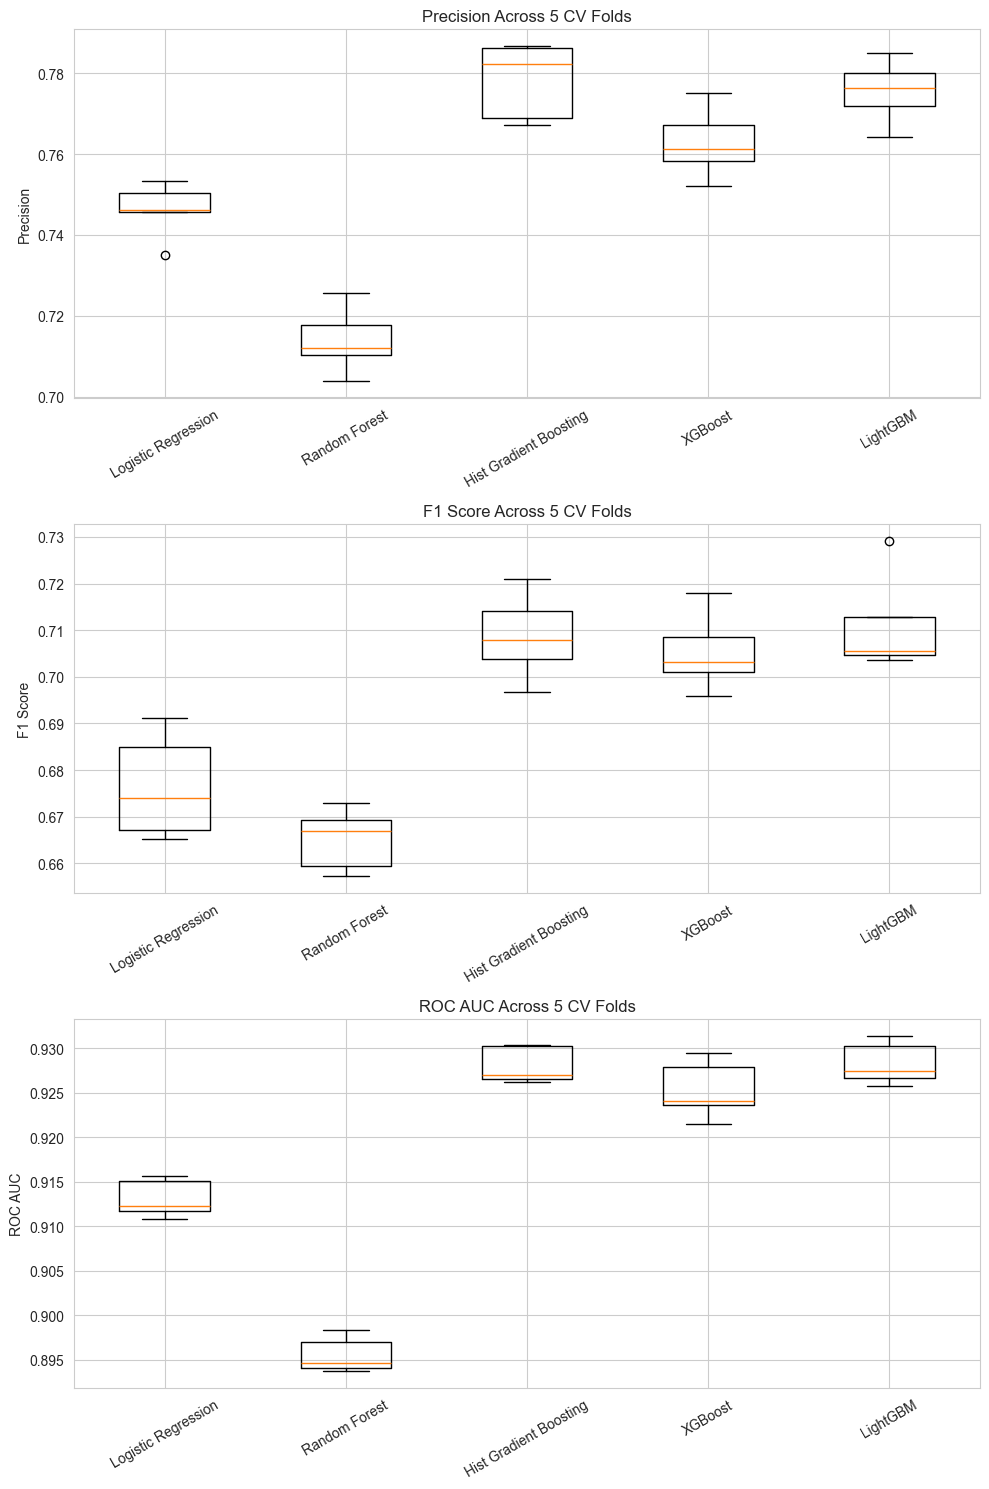

In [51]:
# Visualize the cross-validation scores across all 5 folds

fig, axes = plt.subplots(3,1, figsize=(10, 15))

metric_keys = ["test_precision", "test_f1", "test_roc_auc"]
metric_labels = ["Precision", "F1 Score", "ROC AUC"]

for ax, key, label in zip(axes, metric_keys, metric_labels):

    ax.boxplot(
        [cv_results_raw[model][key] for model in models.keys()],
        tick_labels=models.keys()
    )

    ax.set_title(f"{label} Across 5 CV Folds")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Task 4: Statistical Comparison & Feature Importance

In [54]:
# from scipy import stats (already imported)

# Rank models using the mean Precision across the 5 CV folds
precision_means = {
    model: cv_results_raw[model]["test_precision"].mean()
    for model in models.keys()
}

top2 = sorted(
    precision_means,
    key=precision_means.get,
    reverse=True
)[:2]

scores_a = cv_results_raw[top2[0]]["test_precision"]
scores_b = cv_results_raw[top2[1]]["test_precision"]

# Paired statistical tests
t_stat, p_value_ttest = stats.ttest_rel(scores_a, scores_b)
w_stat, p_value_wilcoxon = stats.wilcoxon(scores_a, scores_b)

print(f"Top 2 Models (by Precision): {top2[0]} vs {top2[1]}")
print()

print(f"Paired t-test")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value     = {p_value_ttest:.4f}")
print()

print(f"Wilcoxon Signed-Rank Test")
print(f"  W-statistic = {w_stat:.4f}")
print(f"  p-value     = {p_value_wilcoxon:.4f}")

Top 2 Models (by Precision): Hist Gradient Boosting vs LightGBM

Paired t-test
  t-statistic = 1.3484
  p-value     = 0.2488

Wilcoxon Signed-Rank Test
  W-statistic = 3.0000
  p-value     = 0.3125


## Statistical Comparison of the Top Two Models

To determine whether the observed difference in Precision between the top two models was statistically significant, two paired statistical tests were performed:

- **Paired t-test** (parametric)
- **Wilcoxon Signed-Rank Test** (non-parametric)

### Hypothesis Testing

**Null Hypothesis (H₀):**

There is **no statistically significant difference** in Precision between HistGradientBoosting and LightGBM across the five cross-validation folds. Any observed difference is due to random variation.

**Alternative Hypothesis (H₁):**

There **is a statistically significant difference** in Precision between HistGradientBoosting and LightGBM.

### Results

| Test | Test Statistic | p-value |
|------|---------------:|--------:|
| Paired t-test | 1.3484 | 0.2488 |
| Wilcoxon Signed-Rank Test | 3.0000 | 0.3125 |

### Interpretation

The significance level was set to **α = 0.05**.

Both tests produced **p-values greater than 0.05**, therefore we **fail to reject the null hypothesis**.

This indicates that there is **no statistically significant difference** in Precision between HistGradientBoosting and LightGBM across the five cross-validation folds.

Although HistGradientBoosting achieved a slightly higher mean Precision (**0.7783**) than LightGBM (**0.7755**), the difference is very small and is likely due to normal variation between folds rather than a true performance advantage.

### Practical Interpretation

From a practical perspective, HistGradientBoosting and LightGBM perform almost identically on this dataset. Since the observed difference is not statistically significant, either model would be a reasonable candidate for further hyperparameter tuning. The final choice could instead be based on practical considerations such as training time, computational resources, or deployment requirements.

In [56]:
# Train Logistic Regression and Random Forest on the full training data

logistic_pipe = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="liblinear",
        random_state=42,
        max_iter=1000
    ))
])

rf_pipe = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

logistic_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001A74D5DEA20>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

In [57]:
rf_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001A74D5DEA20>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

In [60]:
# Extract transformed feature names

feature_names = logistic_pipe.named_steps["preprocessor"].get_feature_names_out()

# Logistic Regression coefficients
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_pipe.named_steps["classifier"].coef_[0]
})

# Random Forest feature importances
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_pipe.named_steps["classifier"].feature_importances_
})

# Keep only engineered features
engineered_keywords = [
    "age_bucket",
    "hours_bucket",
    "has_capital_gain",
    "has_capital_loss",
    "log_capital_gain",
    "log_capital_loss",
    "higher_education",
    "education_hours_interaction"
]

coef_df = coef_df[
    coef_df["Feature"].str.contains("|".join(engineered_keywords))
].copy()

importance_df = importance_df[
    importance_df["Feature"].str.contains("|".join(engineered_keywords))
].copy()

# Sort by absolute coefficient and importance
coef_df["Abs Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Abs Coefficient",
    ascending=False
)

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("=== Logistic Regression Coefficients ===")
display(coef_df[["Feature", "Coefficient"]])

=== Logistic Regression Coefficients ===


,Feature,Coefficient
5,num__has_capital_gain,-3.649902
7,num__log_capital_gain,3.489933
113,cat__age_bucket_65+,-0.908557
114,cat__age_bucket_<25,-0.821578
117,cat__hours_bucket_part-time(<40),-0.759790
6,num__has_capital_loss,-0.671515
110,cat__age_bucket_35-44,0.380354
111,cat__age_bucket_45-54,0.349869
118,cat__hours_bucket_standard(40),-0.272146
10,num__education_hours_interaction,-0.201447


In [59]:
print("\n=== Random Forest Feature Importances ===")
display(importance_df)


=== Random Forest Feature Importances ===


,Feature,Importance
10,num__education_hours_interaction,0.075816
7,num__log_capital_gain,0.050356
9,num__higher_education,0.026621
5,num__has_capital_gain,0.017671
8,num__log_capital_loss,0.017450
111,cat__age_bucket_45-54,0.010706
110,cat__age_bucket_35-44,0.010258
114,cat__age_bucket_<25,0.008679
109,cat__age_bucket_25-34,0.008415
116,cat__hours_bucket_overtime(41-50),0.007125


### Feature Importance & Coefficients

To analyze the impact of the engineered features, I examined the **Random Forest feature importances** and the **Logistic Regression coefficients**.

#### Most Important Engineered Features (Random Forest)
The most influential engineered features were:

1. **education_hours_interaction** (Importance = 0.0758)
2. **log_capital_gain** (Importance = 0.0504)
3. **higher_education** (Importance = 0.0266)
4. **has_capital_gain** (Importance = 0.0177)
5. **log_capital_loss** (Importance = 0.0175)

The remaining engineered features, such as age buckets, hours-per-week buckets, and `has_capital_loss`, contributed less to the model.

#### Largest Logistic Regression Coefficients
The engineered features with the largest absolute coefficients were:

- **has_capital_gain** (-3.6499)
- **log_capital_gain** (3.4899)
- **age_bucket_65+** (-0.9086)
- **age_bucket_<25** (-0.8216)
- **hours_bucket_part-time(<40)** (-0.7598)

These features had the strongest influence on the Logistic Regression model's predictions.

#### Does This Make Sense?

Yes. The results are consistent with the Adult Income dataset. Capital gain is a strong indicator of higher income, so both **`has_capital_gain`** and **`log_capital_gain`** being highly influential is expected. The **`education_hours_interaction`** feature is also important because it captures the combined effect of education level and working hours, which is more informative than considering either feature individually. Features such as **`higher_education`** also align with the expectation that higher educational attainment is associated with a greater likelihood of earning more than \$50K.

### Task 5: Feature Selection

In [61]:
from sklearn.feature_selection import SelectKBest
import time

# Pipeline using all features
full_pipe = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="liblinear",
        random_state=42,
        max_iter=1000
    ))
])

start_full = time.perf_counter()

full_scores = cross_validate(
    full_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

time_full = time.perf_counter() - start_full


# Pipeline with feature selection
selected_pipe = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(
        score_func=mutual_info_classif,
        k=30
    )),
    ("classifier", LogisticRegression(
        solver="liblinear",
        random_state=42,
        max_iter=1000
    ))
])

start_selected = time.perf_counter()

selected_scores = cross_validate(
    selected_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

time_selected = time.perf_counter() - start_selected


print("=== Full Feature Set ===")
print(f"Precision : {full_scores['test_precision'].mean():.4f} ± {full_scores['test_precision'].std():.4f}")
print(f"F1 Score  : {full_scores['test_f1'].mean():.4f} ± {full_scores['test_f1'].std():.4f}")
print(f"ROC AUC   : {full_scores['test_roc_auc'].mean():.4f} ± {full_scores['test_roc_auc'].std():.4f}")
print(f"Training Time: {time_full:.2f} seconds")

print("\n=== SelectKBest (k = 30) ===")
print(f"Precision : {selected_scores['test_precision'].mean():.4f} ± {selected_scores['test_precision'].std():.4f}")
print(f"F1 Score  : {selected_scores['test_f1'].mean():.4f} ± {selected_scores['test_f1'].std():.4f}")
print(f"ROC AUC   : {selected_scores['test_roc_auc'].mean():.4f} ± {selected_scores['test_roc_auc'].std():.4f}")
print(f"Training Time: {time_selected:.2f} seconds")

=== Full Feature Set ===
Precision : 0.7461 ± 0.0062
F1 Score  : 0.6765 ± 0.0101
ROC AUC   : 0.9131 ± 0.0019
Training Time: 11.15 seconds

=== SelectKBest (k = 30) ===
Precision : 0.7492 ± 0.0070
F1 Score  : 0.6589 ± 0.0063
ROC AUC   : 0.9076 ± 0.0017
Training Time: 56.45 seconds


## Feature Selection / Dimensionality Check

### Results

Using **SelectKBest** with **Mutual Information** reduced the feature set before training the Logistic Regression model. The results were compared against the pipeline using all engineered features.

| Metric | Full Feature Set | SelectKBest (k = 30) |
|--------|-----------------:|---------------------:|
| Precision | **0.7461 ± 0.0062** | **0.7492 ± 0.0070** |
| F1 Score | **0.6765 ± 0.0101** | **0.6589 ± 0.0063** |
| ROC AUC | **0.9131 ± 0.0019** | **0.9076 ± 0.0017** |
| Training Time | **11.15 s** | **56.45 s** |

### Discussion

Feature selection produced a **very small increase in Precision** (0.7461 → 0.7492). However, this came at the cost of a **lower F1 Score**, a **lower ROC AUC**, and a **much longer training time** (56.45 s compared to 11.15 s).

Since **Precision** is the primary evaluation metric for this project, the improvement is encouraging. However, the gain is very small (approximately 0.3 percentage points), while the training time increased by roughly **5×** and the other evaluation metrics decreased.

### Decision

For tomorrow's hyperparameter tuning, I will **keep the full engineered feature set** rather than applying SelectKBest. The slight improvement in Precision does not justify the significant increase in computation time or the reduction in F1 Score and ROC AUC. Retaining the complete feature set provides a better overall balance between predictive performance and computational efficiency.